INSTALL AND IMPORT LIBRARIES

In [1]:
!pip install -q scikit-learn pandas joblib matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

LOAD DATASET

In [3]:
heart = fetch_openml(name='heart-statlog', version=1, as_frame=True)
df = heart.frame.copy()
print(df.shape)
df.head()

(270, 14)


,age,sex,chest,resting_blood_pressure,serum_cholestoral,fasting_blood_sugar,resting_electrocardiographic_results,maximum_heart_rate_achieved,exercise_induced_angina,oldpeak,slope,number_of_major_vessels,thal,class
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,present
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,absent
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,present
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,absent
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,absent


In [4]:
df.columns = [c.strip().lower().replace(' ', '_') for c in df.columns]
print(df.columns.tolist())
df.info()

['age', 'sex', 'chest', 'resting_blood_pressure', 'serum_cholestoral', 'fasting_blood_sugar', 'resting_electrocardiographic_results', 'maximum_heart_rate_achieved', 'exercise_induced_angina', 'oldpeak', 'slope', 'number_of_major_vessels', 'thal', 'class']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                                Non-Null Count  Dtype   
---  ------                                --------------  -----   
 0   age                                   270 non-null    int64   
 1   sex                                   270 non-null    int64   
 2   chest                                 270 non-null    int64   
 3   resting_blood_pressure                270 non-null    int64   
 4   serum_cholestoral                     270 non-null    int64   
 5   fasting_blood_sugar                   270 non-null    int64   
 6   resting_electrocardiographic_results  270 non-null    int64   
 7   maximum_heart_rate_ach

In [5]:
target_col = 'class' if 'class' in df.columns else df.columns[-1]
print('Target column:', target_col)
print(df[target_col].value_counts())

Target column: class
class
absent     150
present    120
Name: count, dtype: int64


CLEAN THE DATA

In [6]:
df = df.drop_duplicates()

for col in df.columns:
    if df[col].dtype != 'object' and df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

y_raw = df[target_col].astype(str)
positive_label = sorted(y_raw.unique())[-1]
y = (y_raw == positive_label).astype(int)
X = df.drop(columns=[target_col])

print('Positive class label was:', positive_label)
print(y.value_counts())
print(X.shape)

Positive class label was: present
class
0    150
1    120
Name: count, dtype: int64
(270, 13)


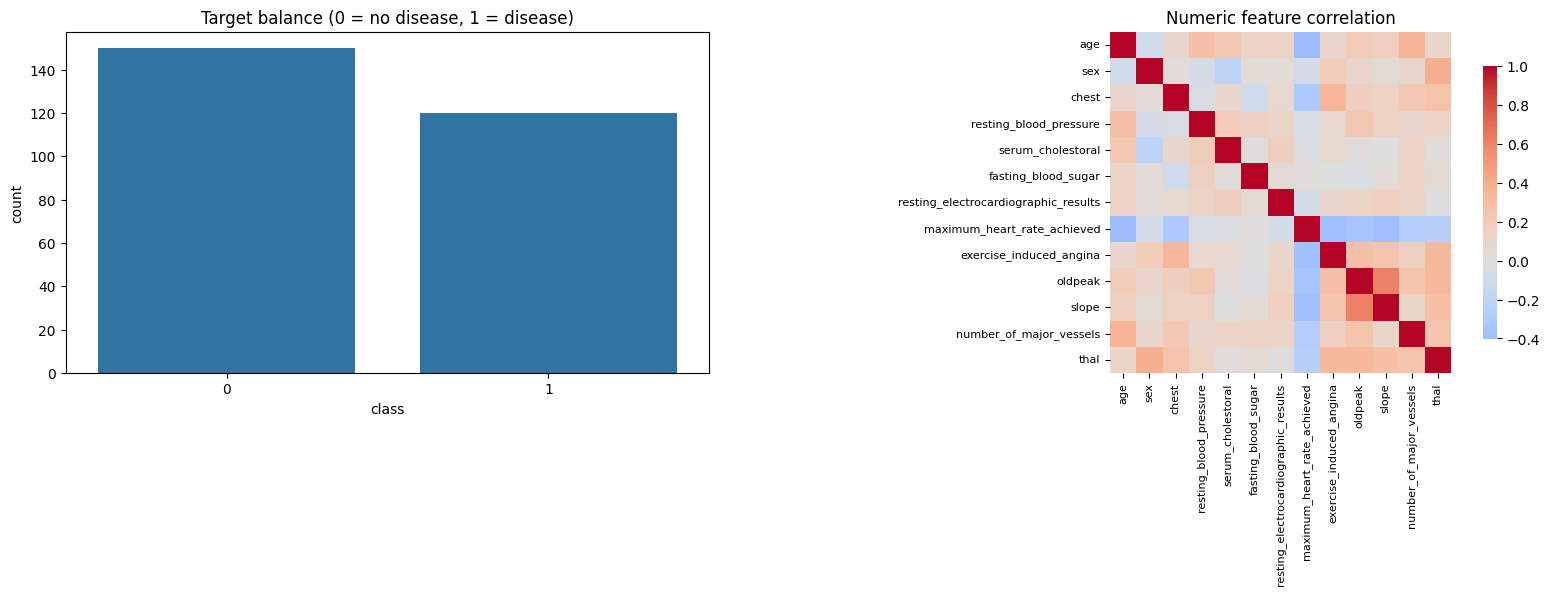

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(x=y, ax=axes[0])
axes[0].set_title('Target balance (0 = no disease, 1 = disease)')

numeric_cols_preview = X.select_dtypes(include=np.number).columns
sns.heatmap(
    X[numeric_cols_preview].corr(),
    cmap='coolwarm', center=0, ax=axes[1],
    annot=False, square=True,
    cbar_kws={'shrink': 0.8}
)
axes[1].set_title('Numeric feature correlation')
axes[1].tick_params(axis='x', labelsize=8, rotation=90)
axes[1].tick_params(axis='y', labelsize=8, rotation=0)

plt.tight_layout()
plt.show()

BUILD THE PREPROCESSING PIPELINE

In [8]:
categorical_cols = [c for c in X.columns if X[c].nunique() <= 10 and X[c].dtype != 'float64']
numeric_cols = [c for c in X.columns if c not in categorical_cols]

print('Categorical columns:', categorical_cols)
print('Numeric columns:', numeric_cols)

Categorical columns: ['sex', 'chest', 'fasting_blood_sugar', 'resting_electrocardiographic_results', 'exercise_induced_angina', 'slope', 'number_of_major_vessels', 'thal']
Numeric columns: ['age', 'resting_blood_pressure', 'serum_cholestoral', 'maximum_heart_rate_achieved', 'oldpeak']


SPLIT TRAIN/TEST

In [9]:
preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale', StandardScaler())
    ]), numeric_cols),
    ('cat', Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), categorical_cols)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)

(216, 13) (54, 13)


TRAIN AND COMPARE MODELS

In [10]:
candidates = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=300, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

results = []
fitted = {}

for name, clf in candidates.items():
    pipe = Pipeline([('prep', preprocessor), ('model', clf)])
    pipe.fit(X_train, y_train)

    preds = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, preds)
    auc = roc_auc_score(y_test, proba)

    results.append({'model': name, 'accuracy': round(acc, 3), 'roc_auc': round(auc, 3)})
    fitted[name] = pipe

results_df = pd.DataFrame(results).sort_values('roc_auc', ascending=False)
results_df

,model,accuracy,roc_auc
0,Logistic Regression,0.870,0.914
1,Random Forest,0.833,0.883
2,Gradient Boosting,0.815,0.867


VISUALIZE COMPARISON

/tmp/ipykernel_1041/300479239.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='model', y='roc_auc', palette='crest')


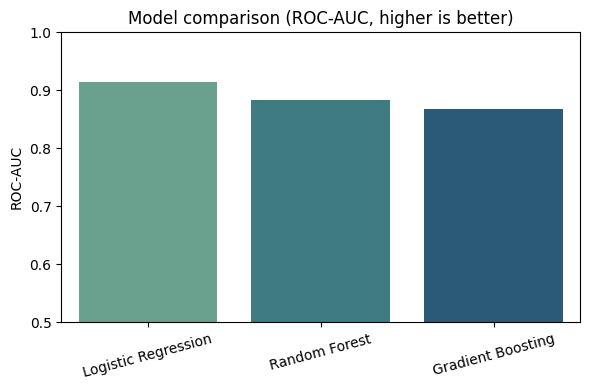

In [11]:
plt.figure(figsize=(6, 4))
sns.barplot(data=results_df, x='model', y='roc_auc', palette='crest')
plt.ylim(0.5, 1.0)
plt.title('Model comparison (ROC-AUC, higher is better)')
plt.ylabel('ROC-AUC')
plt.xlabel('')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

PICK THE BEST MODEL AND CHECK ITS CONFUSION MATRIX


Best model: Logistic Regression
              precision    recall  f1-score   support

           0       0.93      0.83      0.88        30
           1       0.81      0.92      0.86        24

    accuracy                           0.87        54
   macro avg       0.87      0.88      0.87        54
weighted avg       0.88      0.87      0.87        54



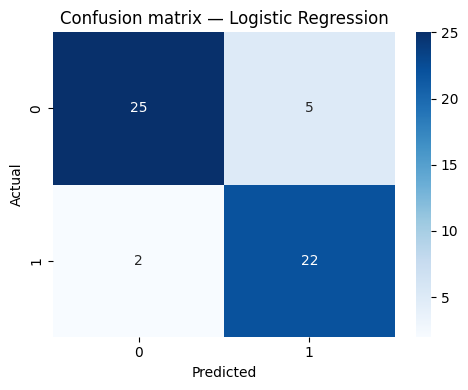

In [12]:
best_name = results_df.iloc[0]['model']
best_pipeline = fitted[best_name]
print('Best model:', best_name)

preds = best_pipeline.predict(X_test)
print(classification_report(y_test, preds))

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, preds), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion matrix — {best_name}')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

In [13]:
model_step = best_pipeline.named_steps['model']
prep_step = best_pipeline.named_steps['prep']

num_names = numeric_cols
cat_names = list(prep_step.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_cols))
all_expanded_names = num_names + cat_names

if hasattr(model_step, 'feature_importances_'):
    raw_importances = model_step.feature_importances_
elif hasattr(model_step, 'coef_'):
    raw_importances = np.abs(model_step.coef_[0])
else:
    raw_importances = np.ones(len(all_expanded_names))

importance_by_original = {c: 0.0 for c in X.columns}
for name, imp in zip(all_expanded_names, raw_importances):
    matched_original = next((c for c in categorical_cols if name.startswith(c + '_')), None)
    original_col = matched_original if matched_original else name
    importance_by_original[original_col] += float(imp)

total = sum(importance_by_original.values()) or 1.0
importance_by_original = {k: v / total for k, v in importance_by_original.items()}

importance_df = pd.DataFrame(
    sorted(importance_by_original.items(), key=lambda x: x[1], reverse=True),
    columns=['feature', 'importance']
)
importance_df

,feature,importance
0,number_of_major_vessels,0.241433
1,chest,0.189334
2,sex,0.130713
3,thal,0.107473
4,slope,0.105108
5,exercise_induced_angina,0.053100
6,fasting_blood_sugar,0.046943
7,resting_blood_pressure,0.029144
8,oldpeak,0.029066
9,maximum_heart_rate_achieved,0.024141


/tmp/ipykernel_1041/4076662183.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, y='feature', x='importance', palette='mako')


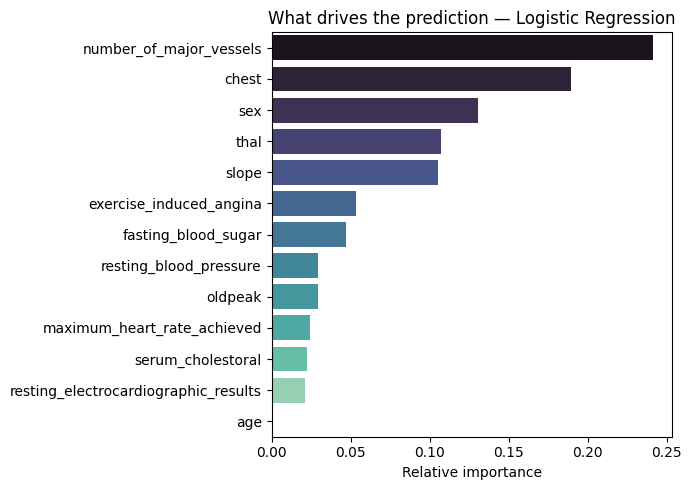

In [14]:
plt.figure(figsize=(7, 5))
sns.barplot(data=importance_df, y='feature', x='importance', palette='mako')
plt.title(f'What drives the prediction — {best_name}')
plt.xlabel('Relative importance')
plt.ylabel('')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

SAVE

In [15]:
feature_info = {'features': [], 'target_labels': {'0': 'Low Risk', '1': 'High Risk'}}

for col in X.columns:
    if col in categorical_cols:
        feature_info['features'].append({
            'name': col,
            'type': 'categorical',
            'options': sorted(X[col].astype(str).unique().tolist()),
            'default': str(X[col].mode()[0])
        })
    else:
        feature_info['features'].append({
            'name': col,
            'type': 'numeric',
            'min': float(X[col].min()),
            'max': float(X[col].max()),
            'default': float(round(X[col].median(), 1))
        })

with open('feature_info.json', 'w') as f:
    json.dump(feature_info, f, indent=2)

insights = {
    'model_name': best_name,
    'model_comparison': results_df.to_dict(orient='records'),
    'global_importance': importance_df.to_dict(orient='records'),
    'numeric_stats': {
        col: {
            'mean': float(X[col].mean()),
            'std': float(X[col].std() or 1.0),
            'importance': float(importance_by_original.get(col, 0.0))
        }
        for col in numeric_cols
    }
}

with open('insights.json', 'w') as f:
    json.dump(insights, f, indent=2)

joblib.dump(best_pipeline, 'model_pipeline.pkl')
print('Saved model_pipeline.pkl, feature_info.json, and insights.json')

Saved model_pipeline.pkl, feature_info.json, and insights.json


DOWNLOAD FILES

In [16]:
from google.colab import files
files.download('model_pipeline.pkl')
files.download('feature_info.json')
files.download('insights.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
import os
required = ['model_pipeline.pkl', 'feature_info.json', 'insights.json']
missing = [f for f in required if not os.path.exists(f)]
print("Missing files:", missing if missing else "None — good to continue!")

Missing files: None — good to continue!


In [18]:
from google.colab import drive
drive.mount('/content/drive')

import shutil, os
save_dir = '/content/drive/MyDrive/heart_risk_project'
os.makedirs(save_dir, exist_ok=True)
for fname in ['model_pipeline.pkl', 'feature_info.json', 'insights.json']:
    shutil.copy(fname, os.path.join(save_dir, fname))
print("Saved to Drive:", save_dir)

Mounted at /content/drive
Saved to Drive: /content/drive/MyDrive/heart_risk_project


In [19]:
!pip install flask -q

In [20]:
import os
os.makedirs('templates', exist_ok=True)
print("Folder ready")

Folder ready


In [21]:
%%writefile app.py
import json
from flask import Flask, render_template, request
import joblib
import pandas as pd

app = Flask(__name__)

model = None
feature_info = None
insights = None
load_error = None

try:
    model = joblib.load("model_pipeline.pkl")
    with open("feature_info.json") as f:
        feature_info = json.load(f)
    with open("insights.json") as f:
        insights = json.load(f)
except Exception as exc:
    load_error = str(exc)


def top_factors_for_patient(row, top_n=3):
    if not insights:
        return []
    scored = []
    for feature, stats in insights.get("numeric_stats", {}).items():
        if feature not in row:
            continue
        value = row[feature]
        mean = stats["mean"]
        std = stats["std"] or 1.0
        importance = stats["importance"]
        z_score = (value - mean) / std
        weighted_score = z_score * importance
        scored.append({
            "feature": feature,
            "value": value,
            "direction": "up" if z_score > 0 else "down",
            "magnitude": abs(weighted_score),
        })
    scored.sort(key=lambda x: x["magnitude"], reverse=True)
    top = scored[:top_n]
    if top:
        max_mag = max(item["magnitude"] for item in top) or 1.0
        for item in top:
            item["bar_pct"] = round(min(item["magnitude"] / max_mag, 1.0) * 100, 1)
    return top


@app.route("/", methods=["GET"])
def home():
    return render_template(
        "index.html",
        features=(feature_info or {}).get("features", []),
        result=None,
        load_error=load_error,
        submitted={},
        insights=insights,
    )


@app.route("/predict", methods=["POST"])
def predict():
    if load_error:
        return render_template(
            "index.html", features=[], result=None,
            load_error=load_error, submitted={}, insights=insights,
        )
    submitted = {}
    try:
        row = {}
        for feat in feature_info["features"]:
            raw_value = request.form.get(feat["name"], "")
            submitted[feat["name"]] = raw_value
            row[feat["name"]] = float(raw_value) if feat["type"] == "numeric" else raw_value

        input_df = pd.DataFrame([row])
        proba = model.predict_proba(input_df)[0]
        classes = list(model.classes_)
        risk_index = classes.index(1) if 1 in classes else int(proba.argmax())
        risk_probability = round(float(proba[risk_index]) * 100, 1)
        prediction = model.predict(input_df)[0]

        label_map = feature_info.get("target_labels", {})
        label = label_map.get(str(prediction), str(prediction))

        result = {
            "label": label,
            "probability": risk_probability,
            "is_high_risk": risk_probability >= 50,
            "top_factors": top_factors_for_patient(row),
        }

        return render_template(
            "index.html", features=feature_info["features"], result=result,
            load_error=None, submitted=submitted, insights=insights,
        )
    except Exception as exc:
        return render_template(
            "index.html", features=feature_info["features"],
            result={"error": f"Couldn't score that input: {exc}"},
            load_error=None, submitted=submitted, insights=insights,
        )


if __name__ == "__main__":
    app.run(host="0.0.0.0", port=5000)

Writing app.py


In [22]:
%%writefile templates/index.html
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>Cardiac Risk Assessment</title>
<link rel="preconnect" href="https://fonts.googleapis.com">
<link href="https://fonts.googleapis.com/css2?family=Fraunces:opsz,wght@9..144,400;9..144,600;9..144,700&family=IBM+Plex+Sans:wght@400;500;600&family=IBM+Plex+Mono:wght@500;600&display=swap" rel="stylesheet">
<style>
  :root{
    --paper:#EEF3F1; --panel:#FFFFFF; --ink:#16262A; --slate:#5B6B6C;
    --line:#CBD6D2; --steel:#3E6B6E; --risk-low:#2E7D6B; --risk-mid:#C99A3E; --risk-high:#C1443B;
  }
  *{ box-sizing:border-box; }
  body{ margin:0; background:var(--paper); color:var(--ink); font-family:'IBM Plex Sans', sans-serif; -webkit-font-smoothing:antialiased; }
  .page{ max-width:1140px; margin:0 auto; padding:48px 24px 80px; }
  header.masthead{ margin-bottom:36px; border-bottom:1px solid var(--line); padding-bottom:24px; }
  .eyebrow{ font-family:'IBM Plex Mono', monospace; font-size:12px; letter-spacing:0.14em; color:var(--steel); text-transform:uppercase; margin:0 0 10px; }
  h1{ font-family:'Fraunces', serif; font-weight:600; font-size:clamp(28px, 4vw, 42px); margin:0; letter-spacing:-0.01em; }
  .sub{ color:var(--slate); margin:10px 0 0; max-width:680px; line-height:1.5; font-size:15px; }
  .layout{ display:grid; grid-template-columns:1.05fr 0.95fr; gap:24px; align-items:start; }
  @media (max-width:860px){ .layout{ grid-template-columns:1fr; } }
  .card{ background:var(--panel); border:1px solid var(--line); border-radius:6px; padding:28px; margin-bottom:24px; }
  .card h2{ font-family:'Fraunces', serif; font-size:19px; font-weight:600; margin:0 0 6px; }
  .card .card-note{ font-size:13px; color:var(--slate); margin:0 0 20px; line-height:1.5; }
  .field-grid{ display:grid; grid-template-columns:1fr 1fr; gap:16px 18px; }
  .field{ display:flex; flex-direction:column; gap:6px; }
  .field label{ font-size:12.5px; color:var(--slate); text-transform:capitalize; }
  .field input, .field select{ font-family:'IBM Plex Mono', monospace; font-size:14px; padding:9px 10px; border:1px solid var(--line); border-radius:4px; background:#FBFDFC; color:var(--ink); }
  .field input:focus, .field select:focus{ outline:2px solid var(--steel); outline-offset:1px; }
  .submit-row{ margin-top:24px; display:flex; align-items:center; gap:14px; flex-wrap:wrap; }
  button.run{ font-family:'IBM Plex Mono', monospace; font-size:13px; letter-spacing:0.04em; text-transform:uppercase; background:var(--ink); color:var(--paper); border:none; padding:13px 22px; border-radius:4px; cursor:pointer; }
  button.run:hover{ background:var(--steel); }
  .hint{ font-size:12.5px; color:var(--slate); }
  .result-card{ position:sticky; top:24px; }
  .gauge-wrap{ display:flex; flex-direction:column; align-items:center; padding-top:6px; }
  .readout{ font-family:'IBM Plex Mono', monospace; text-align:center; margin-top:6px; }
  .readout .pct{ font-size:40px; font-weight:600; line-height:1; }
  .readout .tag{ font-size:12px; letter-spacing:0.1em; text-transform:uppercase; color:var(--slate); margin-top:6px; }
  .badge{ display:inline-block; margin-top:14px; padding:6px 14px; border-radius:999px; font-family:'IBM Plex Mono', monospace; font-size:12.5px; letter-spacing:0.04em; }
  .badge.low{ background:rgba(46,125,107,0.12); color:var(--risk-low); }
  .badge.high{ background:rgba(193,68,59,0.12); color:var(--risk-high); }
  .placeholder{ color:var(--slate); font-size:14px; line-height:1.6; text-align:center; padding:30px 10px 10px; }
  .error-box{ background:rgba(193,68,59,0.08); border:1px solid rgba(193,68,59,0.3); color:var(--risk-high); padding:14px 16px; border-radius:4px; font-size:13.5px; margin-bottom:20px; }
  .bar-row{ display:grid; grid-template-columns:150px 1fr 48px; align-items:center; gap:10px; margin-bottom:10px; }
  .bar-row .bar-label{ font-size:12.5px; color:var(--ink); text-transform:capitalize; }
  .bar-track{ background:#EAF0EE; border-radius:4px; height:9px; overflow:hidden; }
  .bar-fill{ height:100%; border-radius:4px; background:var(--steel); }
  .bar-fill.up{ background:var(--risk-high); }
  .bar-fill.down{ background:var(--risk-low); }
  .bar-value{ font-family:'IBM Plex Mono', monospace; font-size:11.5px; color:var(--slate); text-align:right; }
  .factor-note{ font-size:12.5px; color:var(--slate); margin-top:2px; }
  .comparison-row{ display:flex; justify-content:space-between; font-family:'IBM Plex Mono', monospace; font-size:12.5px; padding:6px 0; border-bottom:1px dashed var(--line); }
  .comparison-row:last-child{ border-bottom:none; }
  .comparison-row .best{ color:var(--steel); font-weight:600; }
  .disclaimer{ margin-top:8px; font-size:12.5px; color:var(--slate); border-top:1px solid var(--line); padding-top:18px; line-height:1.6; }
</style>
</head>
<body>
<div class="page">
  <header class="masthead">
    <p class="eyebrow">Clinical Decision Support &middot</p>
    <h1>Cardiac Risk Assessment</h1>
    <p class="sub">Enter a patient's vitals to estimate heart disease risk.</p>
  </header>

  {% if load_error %}
    <div class="error-box">Model files not found. Detail: {{ load_error }}</div>
  {% endif %}

  <div class="layout">
    <div>
      <section class="card">
        <h2>Patient Vitals</h2>
        <p class="card-note">Fields are pre-filled with typical values — adjust and re-run anytime.</p>
        <form method="POST" action="/predict">
          <div class="field-grid">
            {% for feat in features %}
              <div class="field">
                <label for="{{ feat.name }}">{{ feat.name.replace('_', ' ') }}</label>
                {% if feat.type == 'numeric' %}
                  <input type="number" step="any" id="{{ feat.name }}" name="{{ feat.name }}"
                    min="{{ feat.min }}" max="{{ feat.max }}"
                    value="{{ submitted.get(feat.name, feat.default) }}" required>
                {% else %}
                  <select id="{{ feat.name }}" name="{{ feat.name }}">
                    {% for opt in feat.options %}
                      <option value="{{ opt }}" {% if submitted.get(feat.name, feat.default)|string == opt|string %}selected{% endif %}>{{ opt }}</option>
                    {% endfor %}
                  </select>
                {% endif %}
              </div>
            {% endfor %}
          </div>
          <div class="submit-row">
            <button class="run" type="submit">Assess risk</button>
            <span class="hint">Model used: {{ insights.model_name if insights else '—' }}</span>
          </div>
        </form>
      </section>

      {% if insights %}
      <section class="card">
        <h2>Model Comparison</h2>
        <p class="card-note">Three models were trained and evaluated by ROC-AUC before picking the best one.</p>
        {% for row in insights.model_comparison %}
          <div class="comparison-row">
            <span class="{{ 'best' if row.model == insights.model_name else '' }}">{{ row.model }}{% if row.model == insights.model_name %} (selected){% endif %}</span>
            <span>accuracy {{ row.accuracy }} &nbsp;·&nbsp; ROC-AUC {{ row.roc_auc }}</span>
          </div>
        {% endfor %}
      </section>

      <section class="card">
        <h2>What Drives the Model, Overall</h2>
        <p class="card-note">Global feature importance from the trained model.</p>
        {% for feat in insights.global_importance[:6] %}
          <div class="bar-row">
            <span class="bar-label">{{ feat.feature.replace('_',' ') }}</span>
            <div class="bar-track"><div class="bar-fill" style="width: {{ (feat.importance * 100) | round(1) }}%;"></div></div>
            <span class="bar-value">{{ (feat.importance * 100) | round(1) }}%</span>
          </div>
        {% endfor %}
      </section>
      {% endif %}
    </div>

    <section class="card result-card">
      <h2>Risk Assessment</h2>
      {% if result and result.error %}
        <div class="error-box">{{ result.error }}</div>
      {% elif result %}
        <div class="gauge-wrap">
          <svg id="gauge" viewBox="0 0 220 130" width="220" height="130">
            <path d="M 20 110 A 90 90 0 0 1 82 24" fill="none" stroke="#2E7D6B" stroke-width="14" stroke-linecap="round"/>
            <path d="M 82 24 A 90 90 0 0 1 138 24" fill="none" stroke="#C99A3E" stroke-width="14" stroke-linecap="round"/>
            <path d="M 138 24 A 90 90 0 0 1 200 110" fill="none" stroke="#C1443B" stroke-width="14" stroke-linecap="round"/>
            <line id="needle" x1="110" y1="110" x2="110" y2="30" stroke="#16262A" stroke-width="3" stroke-linecap="round" transform="rotate(0 110 110)"/>
            <circle cx="110" cy="110" r="6" fill="#16262A"/>
          </svg>
          <div class="readout">
            <div class="pct" style="color: {{ '#C1443B' if result.is_high_risk else '#2E7D6B' }};">{{ result.probability }}%</div>
            <div class="tag">Estimated risk score</div>
          </div>
          <span class="badge {{ 'high' if result.is_high_risk else 'low' }}">{{ result.label }}</span>
        </div>
        {% if result.top_factors %}
        <div style="margin-top:26px; padding-top:20px; border-top:1px solid var(--line);">
          <h2 style="font-size:16px;">Top Factors For This Patient</h2>
          <p class="factor-note" style="margin-bottom:14px;">How far this patient's values sit from the dataset average, weighted by feature importance.</p>
          {% for f in result.top_factors %}
            <div class="bar-row">
              <span class="bar-label">{{ f.feature.replace('_',' ') }}</span>
              <div class="bar-track"><div class="bar-fill {{ f.direction }}" style="width: {{ f.bar_pct }}%;"></div></div>
              <span class="bar-value">{{ 'risk ↑' if f.direction == 'up' else 'risk ↓' }}</span>
            </div>
          {% endfor %}
        </div>
        {% endif %}
        <script>
          (function(){
            var probability = {{ result.probability }};
            var angle = -90 + (probability / 100) * 180;
            var needle = document.getElementById('needle');
            needle.style.transition = 'transform 900ms cubic-bezier(0.2, 0.8, 0.2, 1)';
            requestAnimationFrame(function(){
              needle.setAttribute('transform', 'rotate(' + angle + ' 110 110)');
            });
          })();
        </script>
      {% else %}
        <div class="placeholder">Fill in the vitals on the left and click <strong>Assess risk</strong>.</div>
      {% endif %}
      <p class="disclaimer">Educational demo only — not a medical device and not a substitute for professional diagnosis.</p>
    </section>
  </div>
</div>
</body>
</html>

Writing templates/index.html


In [23]:
import threading
import subprocess
from google.colab.output import eval_js

print("👇 CLICK THIS LINK TO OPEN YOUR LIVE APP 👇")
print(eval_js("google.colab.kernel.proxyPort(5000)"))
print("-" * 55)

def run_server():
    subprocess.run(["python", "app.py"])

thread = threading.Thread(target=run_server)
thread.daemon = True
thread.start()
print("Flask server running!")

👇 CLICK THIS LINK TO OPEN YOUR LIVE APP 👇
https://5000-m-s-kkb-usc1b0-32wvds0am49gc-b.us-central1-0.prod.colab.dev
-------------------------------------------------------
Flask server running!
